In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from pca import pca

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

import warnings
warnings.filterwarnings('ignore')

# Референс 
Ссылка на kaggle: https://www.kaggle.com/code/micheldc55/mall-customer-segmentation-model-interpretation#Summary-statistics-of-each-cluster

# Данные 

In [2]:
np.random.seed(42)

# Параметры
n_farms = 10           # количество площадок
n_months = 6           # месяцев (январь - июнь 2024)
farms = [f"Комплекс_{chr(65+i)}" for i in range(n_farms)]  # A, B, C, ..., J
months = list(range(1, n_months + 1))

# Базовая эффективность каждой площадки (своя "генетика")
farm_quality = {
    # Площадка: (базовый_падеж%, базовый_FCR, базовый_ADG_г, базовая_плотность)
    "Комплекс_A": (3.5, 2.75, 810, 11.0),   # эталон
    "Комплекс_B": (4.0, 2.80, 800, 11.2),
    "Комплекс_C": (4.5, 2.85, 790, 11.5),
    "Комплекс_D": (5.5, 2.95, 770, 12.0),
    "Комплекс_E": (6.0, 3.00, 760, 12.5),
    "Комплекс_F": (7.0, 3.10, 740, 13.0),
    "Комплекс_G": (8.0, 3.20, 720, 13.5),   # плохая
    "Комплекс_H": (9.0, 3.30, 700, 14.0),   # очень плохая
    "Комплекс_I": (4.2, 2.82, 795, 11.3),   # середняк
    "Комплекс_J": (10.0, 3.45, 680, 15.0),  # аутсайдер
}

# Сезонные коэффициенты (янв=зима, июнь=лето)
seasonal_factors = {
    1: {"temp": -5, "mortality_effect": 0.0,  "adg_effect": -10},   # зима
    2: {"temp": -3, "mortality_effect": 0.0,  "adg_effect": -5},    
    3: {"temp": 2,  "mortality_effect": 0.0,  "adg_effect": 0},     
    4: {"temp": 8,  "mortality_effect": 0.2,  "adg_effect": 0},   # весна, небольшой рост падежа
    5: {"temp": 15, "mortality_effect": 0.5,  "adg_effect": -5},   # тепло, падеж выше
    6: {"temp": 22, "mortality_effect": 1.0,  "adg_effect": -15},  # жара, падеж сильно выше, привес падает
}

# ======== ГЕНЕРАЦИЯ ========
rows = []

for farm in farms:
    base_mort, base_fcr, base_adg, base_density = farm_quality[farm]
    
    for month in months:
        season = seasonal_factors[month]
        
        # Добавляем сезонные эффекты и немного случайного шума
        
        # Падеж: базовый + сезонный эффект + шум
        mortality = base_mort + season["mortality_effect"] + np.random.normal(0, 0.3)
        mortality = max(1.0, min(25.0, round(mortality, 1)))  # ограничиваем и округляем
        
        # FCR: базовый + шум (обратная корреляция с привесом)
        fcr = base_fcr + np.random.normal(0, 0.05)
        # если жара, FCR ухудшается (больше корма на кг привеса)
        if month >= 5:
            fcr += 0.1
        fcr = round(fcr, 2)
        
        # ADG: базовый + сезонный эффект + шум
        adg = base_adg + season["adg_effect"] + np.random.normal(0, 8)
        adg = max(600, min(850, int(adg)))
        
        # Плотность (меняется медленно, но добавим тренд)
        density = base_density + np.random.normal(0, 0.2)
        density = round(density, 1)
        
        # Служебное: средняя температура за месяц
        temp = season["temp"] + np.random.normal(0, 2)
        temp = round(temp, 1)
        
        rows.append({
            "площадка": farm,
            "год": 2024,
            "месяц": month,
            "падеж_%": mortality,
            "FCR": fcr,
            "ADG_г": adg,
            "плотность_гол_м2": density,
            "температура_ср": temp
        })

df = pd.DataFrame(rows)

In [3]:
df.head()

,площадка,год,месяц,падеж_%,FCR,ADG_г,плотность_гол_м2,температура_ср
0,Комплекс_A,2024,1,3.6,2.74,805,11.3,-5.5
1,Комплекс_A,2024,2,3.4,2.83,811,10.9,-1.9
2,Комплекс_A,2024,3,3.4,2.73,811,10.6,-1.4
3,Комплекс_A,2024,4,3.5,2.70,812,10.8,5.2
4,Комплекс_A,2024,5,4.4,2.84,805,10.7,13.9


# Агрегация

In [4]:
df_agg = df.groupby("площадка").agg({
    "падеж_%": "mean",
    "FCR": "mean",
    "ADG_г": "mean",
    "плотность_гол_м2": "mean",
    "температура_ср": "mean"
}).round(2).reset_index()
df_agg

,площадка,падеж_%,FCR,ADG_г,плотность_гол_м2,температура_ср
0,Комплекс_A,3.80,2.77,807.00,10.87,5.28
1,Комплекс_B,4.25,2.84,791.00,11.15,6.43
2,Комплекс_C,4.83,2.91,785.50,11.50,4.92
3,Комплекс_D,5.58,3.01,761.50,12.08,6.40
4,Комплекс_E,6.48,3.01,749.17,12.52,6.00
5,Комплекс_F,7.22,3.16,739.33,12.93,7.88
6,Комплекс_G,8.32,3.24,714.83,13.50,6.42
7,Комплекс_H,9.52,3.31,694.50,13.90,7.52
8,Комплекс_I,4.23,2.88,784.17,11.40,5.95
9,Комплекс_J,10.22,3.48,677.00,15.05,6.88


# Подготовка к кластеризации

In [5]:
features = ["падеж_%", "FCR", "ADG_г", "плотность_гол_м2"]
X = df_agg[features].values
X

array([[  3.8 ,   2.77, 807.  ,  10.87],
       [  4.25,   2.84, 791.  ,  11.15],
       [  4.83,   2.91, 785.5 ,  11.5 ],
       [  5.58,   3.01, 761.5 ,  12.08],
       [  6.48,   3.01, 749.17,  12.52],
       [  7.22,   3.16, 739.33,  12.93],
       [  8.32,   3.24, 714.83,  13.5 ],
       [  9.52,   3.31, 694.5 ,  13.9 ],
       [  4.23,   2.88, 784.17,  11.4 ],
       [ 10.22,   3.48, 677.  ,  15.05]])

StandardScaler приводит данные к стандартному виду, где среднее значение равно 0, а стандартное отклонение — 1 (Z-стандартизация: (x – mean) / std).

In [6]:
# Создание scaler
scaler = StandardScaler()

# применение scaler только на независимых переменных
X_scaled = scaler.fit_transform(X)

X_scaled

array([[-1.20852567, -1.33704456,  1.36279924, -1.26068703],
       [-1.00291639, -1.01541872,  0.97755564, -1.0427905 ],
       [-0.73790887, -0.69379288,  0.84512815, -0.77041985],
       [-0.39522673, -0.2343274 ,  0.26726275, -0.31906277],
       [ 0.01599183, -0.2343274 , -0.0296156 ,  0.02334606],
       [ 0.35410488,  0.45487083, -0.26654042,  0.34240882],
       [ 0.85670534,  0.82244322, -0.85644468,  0.78598389],
       [ 1.40499676,  1.14406905, -1.34594483,  1.09726464],
       [-1.01205458, -0.83163253,  0.81310477, -0.84824004],
       [ 1.72483342,  1.92516038, -1.76730502,  1.99219679]])

# Выбор оптимального числа кластеров

Внутригрупповая сумма квадратов(within-cluster sum of squares) - сумма квадратов отклонений каждого наблюдения от центроида кластера.

Общая внутригрупповая сумма квадратов(total within-cluster sum of squares) - сумма внутригрупповых сумм квадратов.

Для того, чтобы выяснить, какое число кластеров оптимально, можно многократно проводить кластерный анализ, каждый раз выделяя разное количество кластеров и записывая значение общей внутрикластерной суммы квадратов:

- Если добавление одного кластера в данные значительно понижает общую сумму квадратов, то в увеличении числа кластеров есть смысл;
- Если последующее увеличение кластеров уже не оказывает сильного влияния, значит оптимальное число кластеров найдено;
- Если при увеличении числа кластеров идет плавное снижение общей внтуригрупповой суммы квадратов, значит в данных нет явной кластерной структуры.

## Elbow method (метод локтя)

In [7]:
inertia = []
K_range = range(1, n_farms)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertia.append(kmeans.inertia_)

inertia

[39.99999999999999,
 9.387675298124087,
 3.8680218657074543,
 2.0097524203789026,
 1.236755440349598,
 0.7126559914437389,
 0.3423696106953002,
 0.15512897866208772,
 0.04937742090755771]

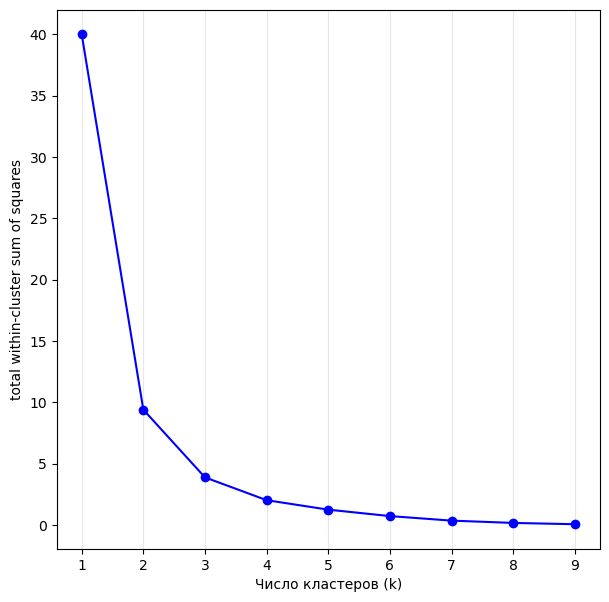

In [8]:
plt.figure(figsize=(7,7))

plt.plot(K_range, inertia, 'bo-', markersize=6)

plt.xlabel('Число кластеров (k)');
plt.ylabel('total within-cluster sum of squares')
plt.grid(axis='x', alpha=0.3)

Мы замечаем, что «локоть» возникает примерно при 3–4 кластерах

## Silhouette scores

Коэффициент силуэта — это метрика, используемая для оценки качества кластеров, созданных алгоритмом кластеризации. Он измеряет, насколько образец схож с собственным кластером по сравнению с другими кластерами. Оценка варьируется от -1 до 1, где более высокая оценка указывает на лучше структурированные кластеры.

Расчет

Коэффициент силуэта для наблюдения вычисляется с использованием средней внутрикластерной дистанции (a) и средней дистанции до ближайшего кластера (b). Формула: (b - a) / max(a, b)

a: Среднее расстояние между образцом и всеми другими точками в том же кластере.

b: Среднее расстояние между образцом и всеми точками ближайшего кластера, в который образец не входит.

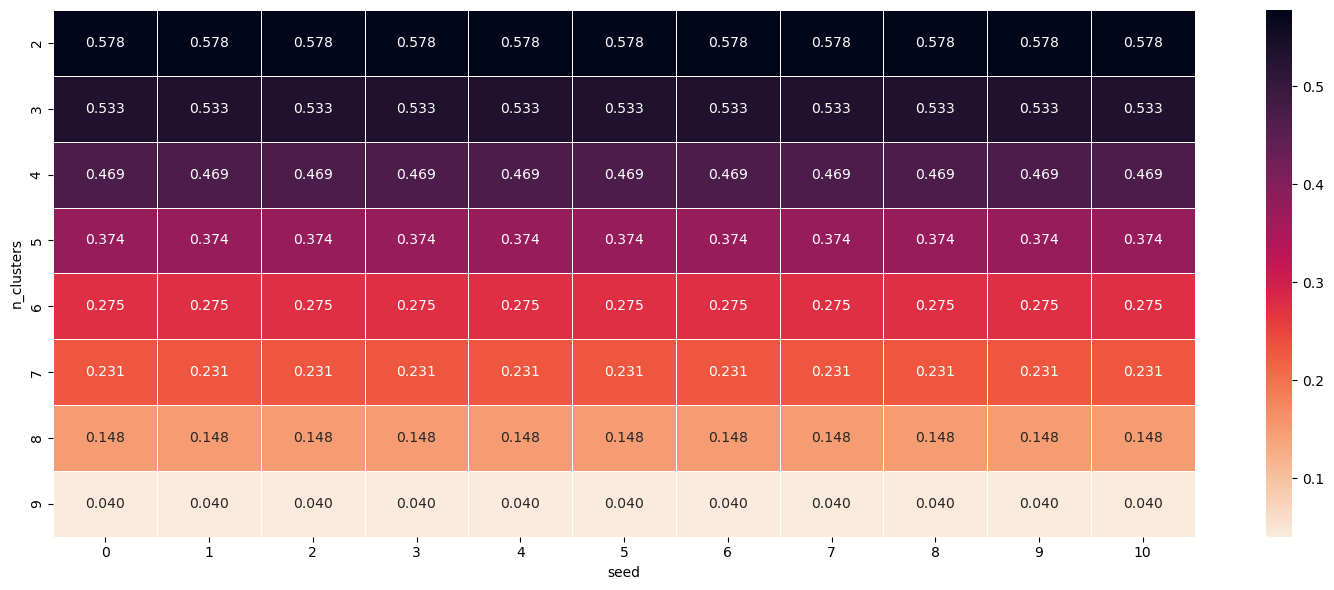

In [9]:
sil_scores = []
K_range = range(2, n_farms) # число кластеров

random_range = range(0, 10+1) # число случаев (повторов эксперимента)

for k in K_range:
    for i in random_range:
        kmeans = KMeans(n_clusters=k, random_state=i, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        silhouette_avg = silhouette_score(X_scaled, labels)
        sil_scores.append([k, i, silhouette_avg])

result = pd.DataFrame(sil_scores, columns=["n_clusters","seed","silhouette_score"])
result_pivot = result.pivot(index="n_clusters", columns="seed", values="silhouette_score")

plt.figure(figsize=(15, 6))
sns.heatmap(result_pivot, annot=True, linewidths=.5, fmt='.3f', cmap=sns.cm.rocket_r)
plt.tight_layout()

Из приведённого выше графика видно, что высокое значение коэффициента сохраянется при 3-4 кластерах, затем снижается, что согласуется с результатами, полученными с помощью метода локтя. 
Эти результаты показывают, что выбор 3 или 4 кластеров должен привести к относительно раздельным группам, что и является нашей целью.

# Кластеризация k-means

In [10]:
# Выбираем K = 3
optimal_k = 3

In [11]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_agg["кластер"] = kmeans.fit_predict(X_scaled)

In [12]:
df_agg

,площадка,падеж_%,FCR,ADG_г,плотность_гол_м2,температура_ср,кластер
0,Комплекс_A,3.80,2.77,807.00,10.87,5.28,2
1,Комплекс_B,4.25,2.84,791.00,11.15,6.43,2
2,Комплекс_C,4.83,2.91,785.50,11.50,4.92,2
3,Комплекс_D,5.58,3.01,761.50,12.08,6.40,0
4,Комплекс_E,6.48,3.01,749.17,12.52,6.00,0
5,Комплекс_F,7.22,3.16,739.33,12.93,7.88,0
6,Комплекс_G,8.32,3.24,714.83,13.50,6.42,1
7,Комплекс_H,9.52,3.31,694.50,13.90,7.52,1
8,Комплекс_I,4.23,2.88,784.17,11.40,5.95,2
9,Комплекс_J,10.22,3.48,677.00,15.05,6.88,1


In [13]:
kmeans.labels_

array([2, 2, 2, 0, 0, 0, 1, 1, 2, 1])

# 2D Визуализация с помощью PCA

Для визуализации понадобится PCA.

Метод анализа главных компонент (PCA, Principal Component Analysis) - это статистический метод, используемый для снижения размерности данных. Он позволяет выделить наиболее существенные переменные (главные компоненты), объясняющие наибольшую часть изменчивости в исходных данных. Изначальное(до сортировки) число главных компонент всегда равняется исходному числу переменных.

In [14]:
# модель PCA с 2-мя компонентами
model = pca(n_components=2, normalize=True) # сделает стандартизацию
X_pca = model.fit_transform(df_agg[features]) # здесь передаю не просто значения, а df, тк нужны названия столбцов для графика

[03-05-2026 11:06:04] [pca.pca] [INFO] Extracting column labels from dataframe.
[03-05-2026 11:06:04] [pca.pca] [INFO] Extracting row labels from dataframe.
[03-05-2026 11:06:04] [pca.pca] [INFO] Normalizing input data per feature (zero mean and unit variance)..
[03-05-2026 11:06:04] [pca.pca] [INFO] The PCA reduction is performed on the 4 columns of the input dataframe.
[03-05-2026 11:06:04] [pca.pca] [INFO] Fit using PCA.
[03-05-2026 11:06:04] [pca.pca] [INFO] Compute loadings and PCs.
[03-05-2026 11:06:04] [pca.pca] [INFO] Compute explained variance.
[03-05-2026 11:06:04] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[2]
[03-05-2026 11:06:04] [pca.pca] [INFO] Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[03-05-2026 11:06:04] [pca.pca] [INFO] Outlier detection using SPE/DmodX with n_std=[3]


In [15]:
X_pca

{'loadings':       падеж_%       FCR     ADG_г  плотность_гол_м2
 PC1 -0.499619 -0.499676  0.500393         -0.500312
 PC2  0.623426 -0.599257 -0.342862         -0.366984,
 'PC':         PC1       PC2
 0  2.584563  0.043208
 1  2.019339  0.030774
 2  1.523691 -0.051301
 3  0.607918 -0.080515
 4  0.082598  0.151979
 5 -0.708892 -0.086099
 6 -1.660777  0.046436
 7 -2.496102  0.249114
 8  1.752445 -0.100071
 9 -3.704782 -0.203524,
 'explained_var': array([0.99358554, 0.99753776]),
 'variance_ratio': array([0.99358554, 0.00395223]),
 'model': PCA(n_components=2),
 'scaler': StandardScaler(),
 'pcp': 0.9975377637600586,
 'topfeat':     PC           feature   loading  type
 0  PC1             ADG_г  0.500393  best
 1  PC2           падеж_%  0.623426  best
 2  PC2               FCR -0.599257  weak
 3  PC1  плотность_гол_м2 -0.500312  weak,
 'outliers':     y_proba     p_raw   y_score  y_bool  y_bool_spe  y_score_spe
 0  0.821509  0.244403  5.447273   False       False     2.584924
 1  0.89553

(<Figure size 1500x1000 with 1 Axes>,
 <Axes: title={'center': 'Cumulative explained variance\n 2 Principal Components explain [99.75%] of the variance.'}, xlabel='Principal Component', ylabel='Percentage explained variance'>)

<Figure size 600x600 with 0 Axes>

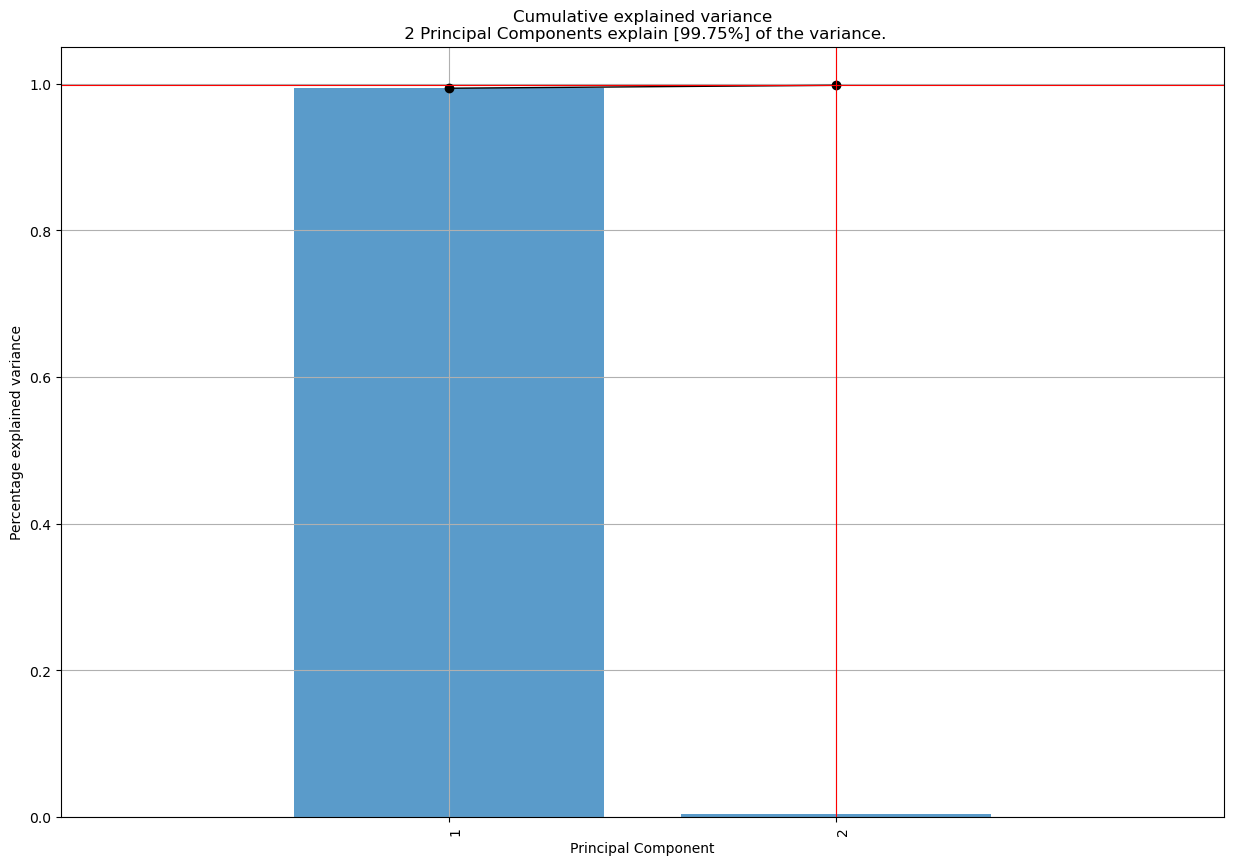

In [16]:
plt.figure(figsize=(6,6))
model.plot()

In [17]:
print(f'explained_var: {model.results['explained_var']}')
print(f'variance_ratio: {model.results['variance_ratio']}')

explained_var: [0.99358554 0.99753776]
variance_ratio: [0.99358554 0.00395223]


Первая главная компонента (PC1) объясняет 0.994 изменчивости исходных данных.  
Вторая компонента (PC2) объясняет оставшиеся 0.004 изменчивости. 

Длина стрелки: 
- Чем длиннее стрелка, тем сильнее этот признак влияет на расположение точек на графике. Короткая стрелка = этот признак почти не объясняет разницу между площадками.

Направление стрелок:
- Если две стрелки смотрят в одну сторону → признаки положительно коррелируют

- Если стрелки смотрят в противоположные стороны → отрицательная корреляция

- Если угол между переменными равен 90 градусов, значит коэффициент корреляции межу ними равняется нулю.



[03-05-2026 11:06:05] [pca.pca] [INFO] Plot PC1 vs PC2 with loadings.
[03-05-2026 11:06:05] [scatterd.scatterd] [INFO] Create scatterplot


<Figure size 600x600 with 0 Axes>

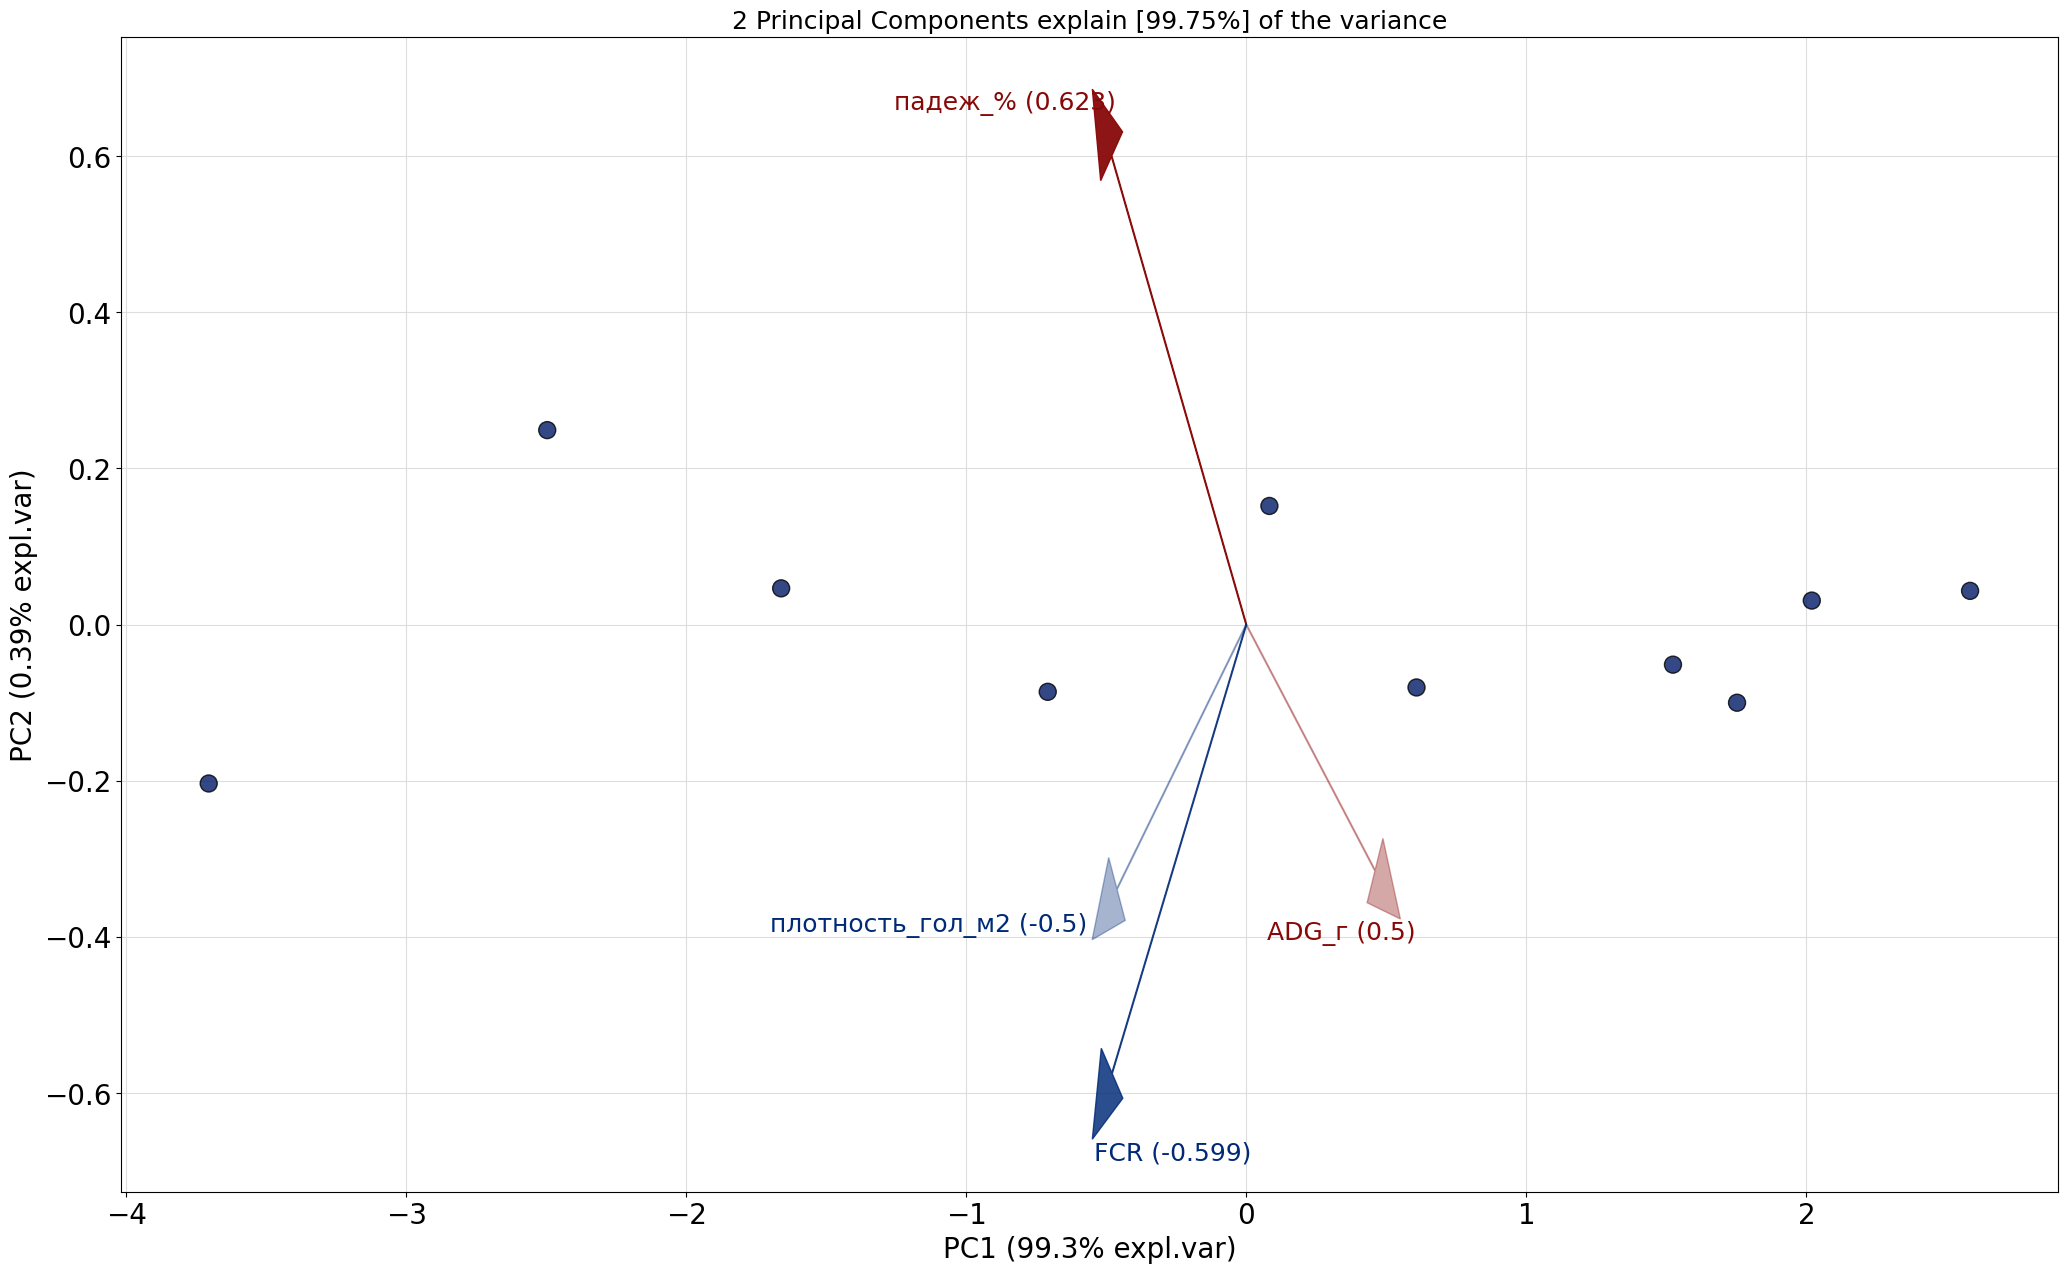

In [18]:
plt.figure(figsize=(6,6))
model.biplot();

"На biplot стрелки FCR и ADG направлены в одну сторону, однако корреляционный анализ показывает отрицательную связь (−0.99). Это связано с тем, что 2D-проекция PCA искажает оригинальные углы между признаками. При интерпретации мы опираемся на числовые корреляции."

In [19]:
df_agg

,площадка,падеж_%,FCR,ADG_г,плотность_гол_м2,температура_ср,кластер
0,Комплекс_A,3.80,2.77,807.00,10.87,5.28,2
1,Комплекс_B,4.25,2.84,791.00,11.15,6.43,2
2,Комплекс_C,4.83,2.91,785.50,11.50,4.92,2
3,Комплекс_D,5.58,3.01,761.50,12.08,6.40,0
4,Комплекс_E,6.48,3.01,749.17,12.52,6.00,0
5,Комплекс_F,7.22,3.16,739.33,12.93,7.88,0
6,Комплекс_G,8.32,3.24,714.83,13.50,6.42,1
7,Комплекс_H,9.52,3.31,694.50,13.90,7.52,1
8,Комплекс_I,4.23,2.88,784.17,11.40,5.95,2
9,Комплекс_J,10.22,3.48,677.00,15.05,6.88,1


# Еще визуализация PCA

In [20]:
X_pca_df = X_pca['PC']
X_pca_df['Кластер'] = kmeans.labels_
X_pca_df['Кластер'] = X_pca_df['Кластер'].astype(str)
X_pca_df

,PC1,PC2,Кластер
0,2.584563,0.043208,2
1,2.019339,0.030774,2
2,1.523691,-0.051301,2
3,0.607918,-0.080515,0
4,0.082598,0.151979,0
5,-0.708892,-0.086099,0
6,-1.660777,0.046436,1
7,-2.496102,0.249114,1
8,1.752445,-0.100071,2
9,-3.704782,-0.203524,1


In [21]:
import plotly.express as px

fig = px.scatter(X_pca_df, x='PC1', y='PC2',
              color=X_pca_df['Кластер'])
fig.show()

# Интерпретация кластеров

In [31]:
# описательные статистики по всем данным
df_agg.describe().T

,count,mean,std,min,25%,50%,75%,max
падеж_%,10.0,6.445,2.307005,3.80,4.3950,6.030,8.0450,10.22
FCR,10.0,3.061,0.229417,2.77,2.8875,3.010,3.2200,3.48
ADG_г,10.0,750.400,43.778744,677.00,720.9550,755.335,785.1675,807.00
плотность_гол_м2,10.0,12.490,1.354523,10.87,11.4250,12.300,13.3575,15.05
температура_ср,10.0,6.368,0.911260,4.92,5.9625,6.410,6.7675,7.88
кластер,10.0,1.100,0.875595,0.00,0.2500,1.000,2.0000,2.00


In [ ]:
# Строит гистограммы распределения по всем факторам. Сейчас в этом нет смысла, тк в кластерах немного значений. 
# df_agg[df_agg['кластер'] == 2].hist(figsize=(15,15));

In [32]:
df_agg[df_agg['кластер'] == 2].describe().T

,count,mean,std,min,25%,50%,75%,max
падеж_%,4.0,4.2775,0.422798,3.80,4.1225,4.240,4.3950,4.83
FCR,4.0,2.8500,0.060553,2.77,2.8225,2.860,2.8875,2.91
ADG_г,4.0,791.9175,10.480644,784.17,785.1675,788.250,795.0000,807.00
плотность_гол_м2,4.0,11.2300,0.281543,10.87,11.0800,11.275,11.4250,11.50
температура_ср,4.0,5.6450,0.675302,4.92,5.1900,5.615,6.0700,6.43
кластер,4.0,2.0000,0.000000,2.00,2.0000,2.000,2.0000,2.00


Для кластера 2 характерны: падеж ниже среднего, FCR (конверсия корма) ниже среднего, ADG_г (привес) выше среднего, плотность голов ниже среднего.

In [33]:
df_agg[df_agg['кластер'] == 1].describe().T

,count,mean,std,min,25%,50%,75%,max
падеж_%,3.0,9.353333,0.960902,8.32,8.920,9.52,9.870,10.22
FCR,3.0,3.343333,0.123423,3.24,3.275,3.31,3.395,3.48
ADG_г,3.0,695.443333,18.932634,677.00,685.750,694.50,704.665,714.83
плотность_гол_м2,3.0,14.150000,0.804674,13.50,13.700,13.90,14.475,15.05
температура_ср,3.0,6.940000,0.552449,6.42,6.650,6.88,7.200,7.52
кластер,3.0,1.000000,0.000000,1.00,1.000,1.00,1.000,1.00


Для кластера 1 характерны: падеж выше среднего, FCR (конверсия корма) выше среднего, ADG_г (привес) ниже среднего, плотность голов выше среднего.

In [34]:
df_agg[df_agg['кластер'] == 0].describe().T

,count,mean,std,min,25%,50%,75%,max
падеж_%,3.0,6.426667,0.821300,5.58,6.03,6.48,6.850,7.22
FCR,3.0,3.060000,0.086603,3.01,3.01,3.01,3.085,3.16
ADG_г,3.0,750.000000,11.108281,739.33,744.25,749.17,755.335,761.50
плотность_гол_м2,3.0,12.510000,0.425088,12.08,12.30,12.52,12.725,12.93
температура_ср,3.0,6.760000,0.990353,6.00,6.20,6.40,7.140,7.88
кластер,3.0,0.000000,0.000000,0.00,0.00,0.00,0.000,0.00


Для кластера 0 характерны: падеж, FCR (конверсия корма), ADG_г (привес), плотность голов около среднего.

# Использование центроидов для интерпретации

Использование центроидов кластеров как средства понимания самих кластеров.
Когда нам нужно быстро получить представление о статистике кластеров по каждому кластеру, мы также можем использовать центроиды каждого кластера, как показано ниже. Проблема этого метода в том, что он дает представление о центральной тенденции, но не раскрывает всей картины. Выбросы могут влиять на значения каждого центроида, поэтому эту метрику нужно применять с осторожностью.

Тем не менее, это будет хорошей мерой точности для уже созданных нами кластеров.

In [42]:
centroids = kmeans.cluster_centers_
centroids

array([[-0.00837667, -0.00459465, -0.00963109,  0.01556404],
       [ 1.32884518,  1.29722422, -1.32323151,  1.2918151 ],
       [-0.99035138, -0.96947217,  0.99964695, -0.98053436]])

In [49]:
pd.DataFrame(centroids, 
            columns = df_agg.columns[1:len(features)+1], 
            index = ['C0', 'C1', 'C2']
            )

,падеж_%,FCR,ADG_г,плотность_гол_м2
C0,-0.008377,-0.004595,-0.009631,0.015564
C1,1.328845,1.297224,-1.323232,1.291815
C2,-0.990351,-0.969472,0.999647,-0.980534


Вы можете использовать информацию из центроида, чтобы получить некоторое представление о данных, но, как и в случае с метриками центральной тенденции, вы, как правило, недооцениваете свои описания, так как центроиды не обязательно показывают полную картину данных внутри каждого кластера. 
Числовые признаки, а также некоторые категориальные признаки труднее интерпретировать. Именно поэтому мы предпочитаем метод дерева решений, показанный ниже.

# Дерево решений для интерпретации кластеров

In [52]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import graphviz

In [136]:
# создаем классификатор
clf = DecisionTreeClassifier(criterion='gini', 
                             max_depth=6, 
                             min_samples_leaf=1, 
                             random_state=42)

In [137]:
X = df_agg[['падеж_%','FCR', 'ADG_г', 'плотность_гол_м2']]
X.head()

,падеж_%,FCR,ADG_г,плотность_гол_м2
0,3.80,2.77,807.00,10.87
1,4.25,2.84,791.00,11.15
2,4.83,2.91,785.50,11.50
3,5.58,3.01,761.50,12.08
4,6.48,3.01,749.17,12.52


In [138]:
y = df_agg['кластер']
y.head()

0    2
1    2
2    2
3    0
4    0
Name: кластер, dtype: int32

In [139]:
clf.fit(X, y)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [140]:
from sklearn.metrics import classification_report, confusion_matrix

In [141]:
predictions = clf.predict(X)
print(classification_report(y, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         4

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



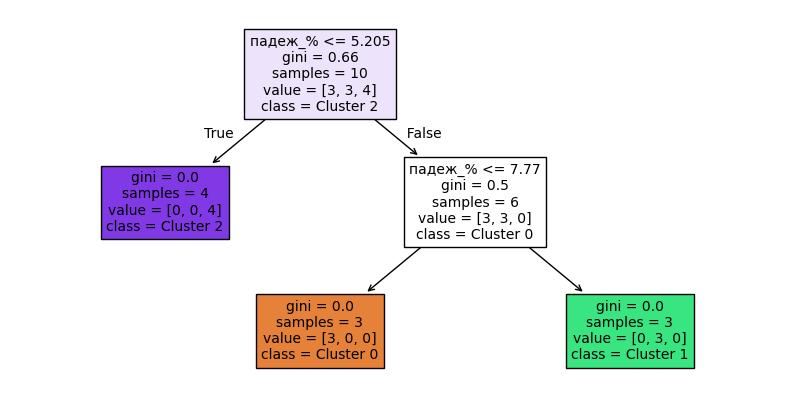

In [142]:
plt.figure(figsize=(10,5))
tree.plot_tree(clf, 
               feature_names=list(X),
               class_names=['Cluster 0', 'Cluster 1', 'Cluster 2'],
               filled=True,
               fontsize=10
               );

Кластеры согласно решающему дереву:
Мы можем увидеть интерпретацию каждого кластера в зависимости от признаков, которые разделяют площадки на ту или иную группу.
Интересный факт о решающем дереве заключается в том, что его можно обрезать, учитывая только самые важные признаки, и таким образом оно предоставляет гораздо более простую версию, которую легче суммировать, как показано ниже. Мы будем использовать кластеры, полученные этим методом, по причинам, объясненным ранее.

Обратите внимание, что есть кластеры, такие как кластер 2, для которых нужно знать только 1 признак - падеж_%, чтобы отнести его к кластеру 2. Это очень простое правило для практического применения.

# Корреляции переменных

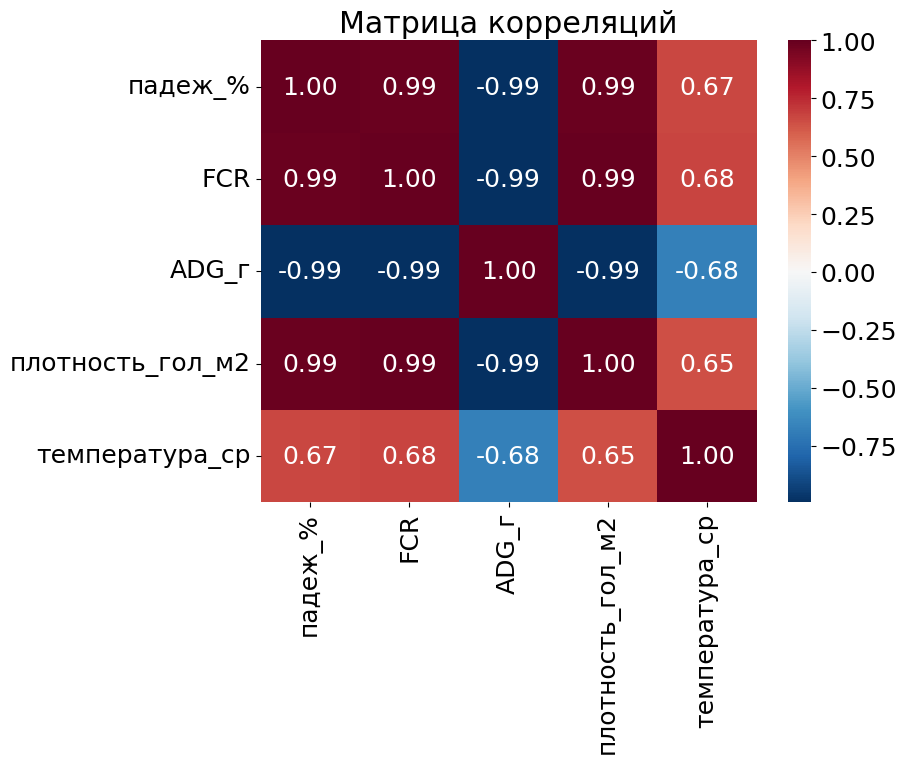

In [144]:
corr_matrix = df_agg[["падеж_%", "FCR", "ADG_г", "плотность_гол_м2", "температура_ср"]].corr()

# Тепловая карта
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title("Матрица корреляций")
plt.show()

# Иерархическая кластеризация

In [145]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
point_array = np.array(df_agg[["падеж_%", "FCR", "ADG_г", "плотность_гол_м2", "температура_ср"]])
point_array

array([[  3.8 ,   2.77, 807.  ,  10.87,   5.28],
       [  4.25,   2.84, 791.  ,  11.15,   6.43],
       [  4.83,   2.91, 785.5 ,  11.5 ,   4.92],
       [  5.58,   3.01, 761.5 ,  12.08,   6.4 ],
       [  6.48,   3.01, 749.17,  12.52,   6.  ],
       [  7.22,   3.16, 739.33,  12.93,   7.88],
       [  8.32,   3.24, 714.83,  13.5 ,   6.42],
       [  9.52,   3.31, 694.5 ,  13.9 ,   7.52],
       [  4.23,   2.88, 784.17,  11.4 ,   5.95],
       [ 10.22,   3.48, 677.  ,  15.05,   6.88]])

In [149]:
Z = linkage(point_array, 'ward') # Вычисление расстояний

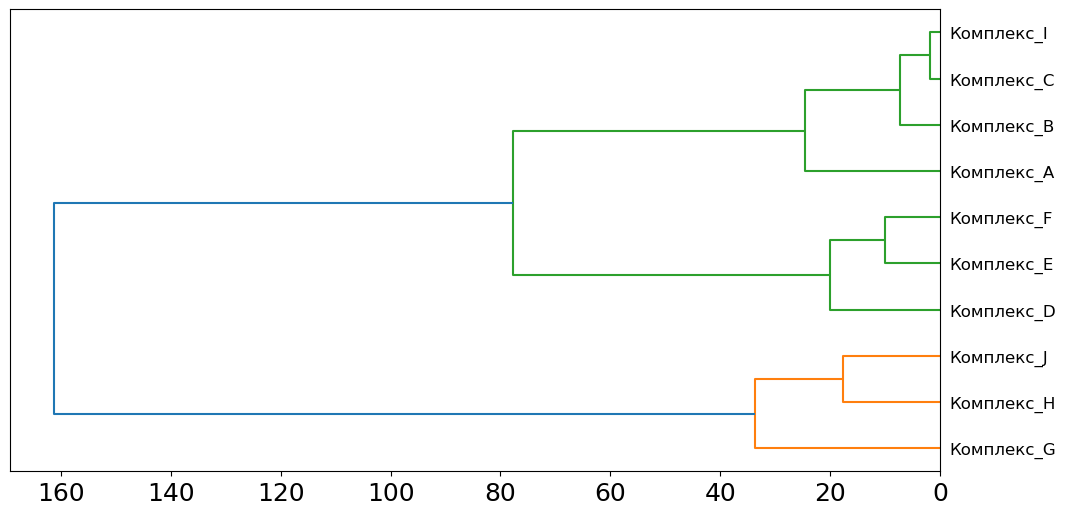

In [159]:
plt.figure(figsize=(12,6))
dn = dendrogram(Z, labels=list(df_agg['площадка']), orientation='left') # Построение дендрограммы